In [1]:
!pip install skimpy xgboost catboost mlflow lightgbm polars shap imblearn plotly arch hmmlearn --quiet

In [2]:
import pandas as pd
import numpy as np
import skimpy as sk
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from arch import arch_model
import mlflow
import mlflow.sklearn
import os
import shutil
import scipy.stats as ss
import shap
import hmmlearn
from warnings import filterwarnings; filterwarnings("ignore")
from concurrent.futures import ThreadPoolExecutor, as_completed
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.metrics import *
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingRegressor, ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from hmmlearn.hmm import GaussianHMM
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [3]:
train = pd.read_csv("/content/drive/MyDrive/zindi_data/Train.csv")
test = pd.read_csv("/content/drive/MyDrive/zindi_data/Test.csv")

In [4]:
sk.skim(train)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                 Data Types                                                                │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                         │
│ ┃ Dataframe         ┃ Values  ┃ ┃ Column Type ┃ Count ┃                                                         │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                         │
│ │ Number of rows    │ 2154021 │ │ float64     │ 11    │                                                         │
│ │ Number of columns │ 13      │ │ string      │ 2     │                                                         │
│ └───────────────────┴─────────┘ └─────────────┴───────┘                                                         │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column           ┃ NA ┃ NA % ┃ mean      ┃ sd     ┃ p0     ┃ p25     ┃ p50       ┃ p75    ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ lat              │  0 │    0 │     33.08 │  32.19 │  -55.5 │     9.5 │      40.5 │   59.5 │  83.5 │ ▁▃▄▅█▇ │  │
│ │ lon              │  0 │    0 │     17.51 │  85.32 │ -179.5 │   -63.5 │      27.5 │   90.5 │ 179.5 │ ▁▇▃█▇▄ │  │
│ │ TWS_t            │  0 │    0 │     0.117 │  0.913 │ -3.968 │ -0.5267 │    0.1315 │ 0.7858 │ 4.057 │  ▁▇█▁  │  │
│ │ SPEI_01_t        │  0 │    0 │  -0.03037 │ 0.9565 │ -4.248 │ -0.7485 │  -0.05587 │ 0.6661 │ 3.476 │  ▁▆█▃  │  │
│ │ SPEI_03_t        │  0 │    0 │  -0.05532 │ 0.9444 │ -5.225 │ -0.7611 │  -0.07611 │ 0.6314 │ 4.177 │   ▅█▂  │  │
│ │ SPEI_06_t        │  0 │    0 │  -0.07057 │ 0.9399 │ -4.383 │ -0.7696 │  -0.08941 │ 0.6098 │  4.85 │   ▂█▅  │  │
│ │ SPEI_12_t        │  0 │    0 │  -0.09327 │ 0.9307 │ -4.622 │ -0.7793 │   -0.1135 │  0.575 │ 3.765 │   ▆█▂  │  │
│ │ SOIL_MOISTURE_t  │  0 │    0 │ 0.0007793 │ 0.7875 │ -5.107 │ -0.4452 │ 0.0006545 │ 0.5027 │ 5.385 │    █▆  │  │
│ │ month_sin        │  0 │    0 │   0.01119 │ 0.7045 │     -1 │    -0.5 │ 1.225e-16 │    0.5 │     1 │ █▅▃▂▆█ │  │
│ │ month_cos        │  0 │    0 │    0.0255 │ 0.7092 │     -1 │    -0.5 │ 6.123e-17 │  0.866 │     1 │ ▇▅▃▂▅█ │  │
│ │ target           │  0 │    0 │    0.1125 │  0.912 │ -3.968 │ -0.5294 │    0.1273 │ 0.7807 │ 4.057 │  ▁▇█▁  │  │
│ └──────────────────┴────┴──────┴───────────┴────────┴────────┴─────────┴───────────┴────────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ sample_id │  0 │    0 │ 20020501_ │ 20020501_ │ 20020501_ │ 20150801_ │      18.7 │         1 │    2154021 │  │
│ │           │    │      │ 0.5_9.5   │ -55.5_-68 │ -0.5_-48. │ 9.5_99.5  │           │           │            │  │
│ │           │    │      │           │ .5        │ 5         │           │           │           │            │  │
│ │ time      │  0 │    0 │ 2002-05-0 │ 2002-05-0 │ 2002-05-0 │ 2015-08-0 │        10 │         1 │    2154021 │  │
│ │           │    │      │ 1         │ 1         │ 1         │ 1         │           │           │            │  │
│ └───────────┴────┴──────┴───────────┴───────────┴─────

In [5]:
train.isnull().sum()

,0
sample_id,0
time,0
lat,0
lon,0
TWS_t,0
SPEI_01_t,0
SPEI_03_t,0
SPEI_06_t,0
SPEI_12_t,0
SOIL_MOISTURE_t,0


## EDA

<Axes: xlabel='target'>

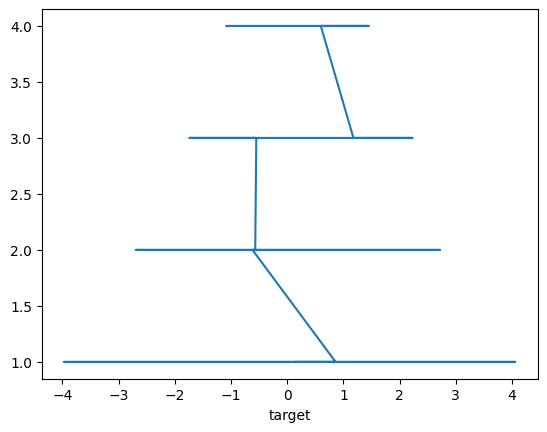

In [6]:
train["target"].value_counts().plot(kind="line")

In [7]:
train["target"]

,target
0,0.207665
1,0.634465
2,-0.337083
3,-0.148142
4,0.089539
...,...
2154016,-0.274003
2154017,-0.271390
2154018,-0.268540
2154019,-0.265412


<Axes: >

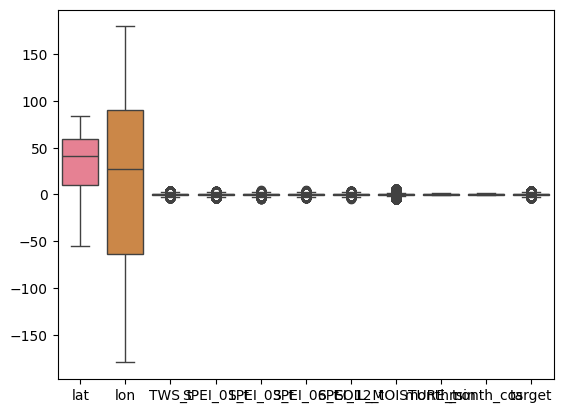

In [8]:
##Checking for Outliers
sns.boxplot(train)

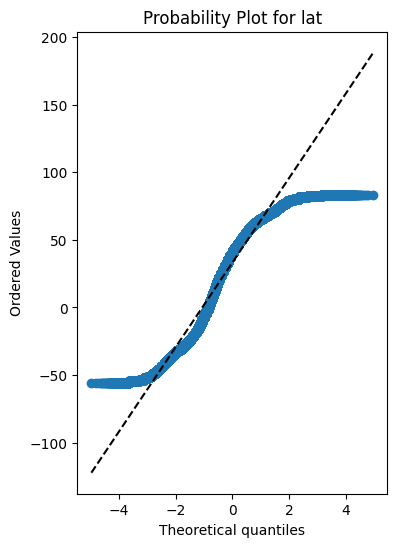

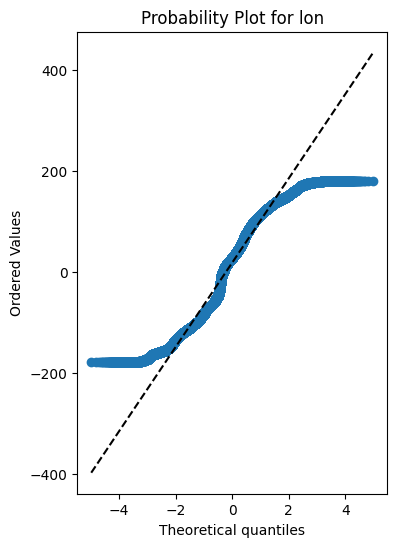

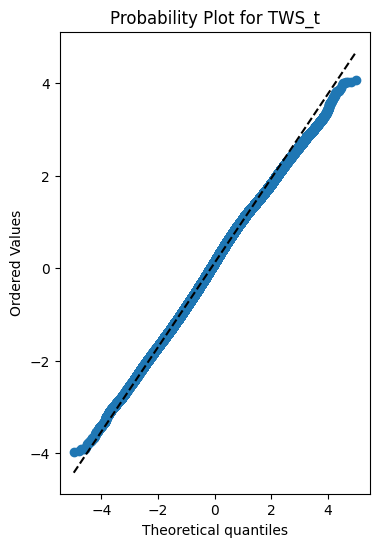

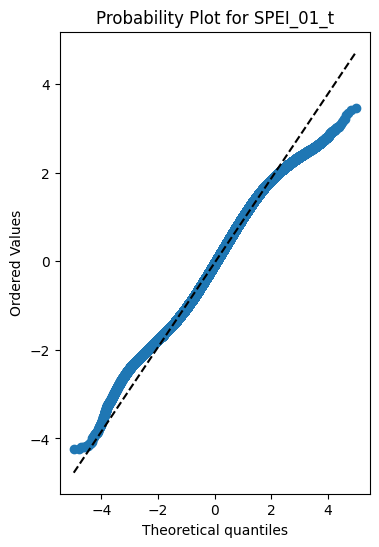

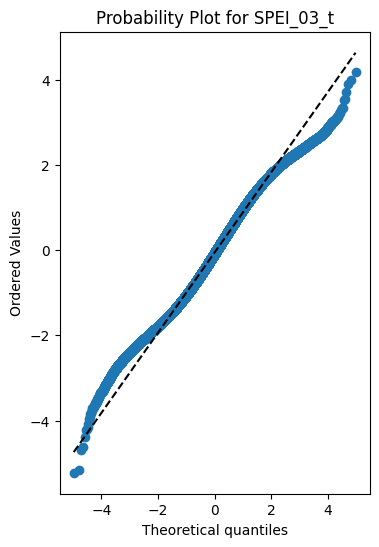

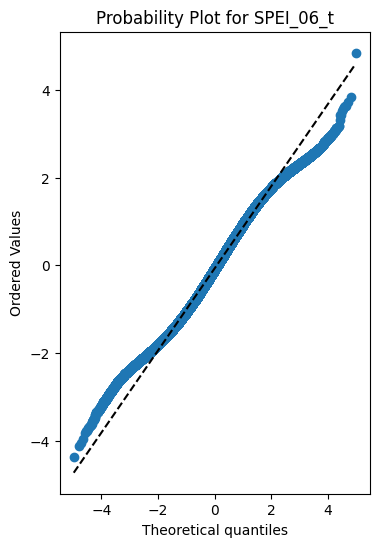

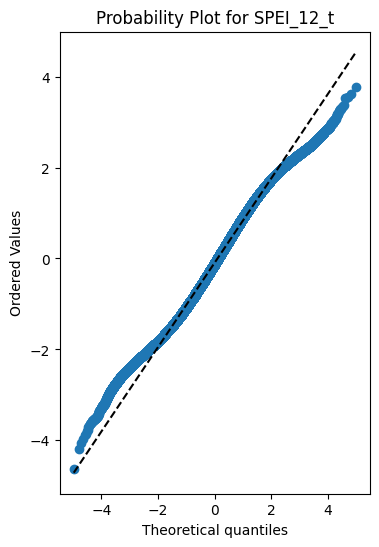

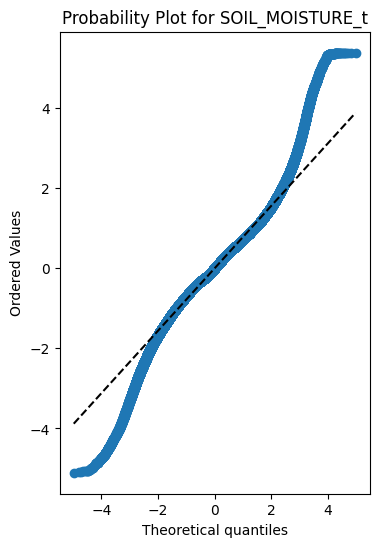

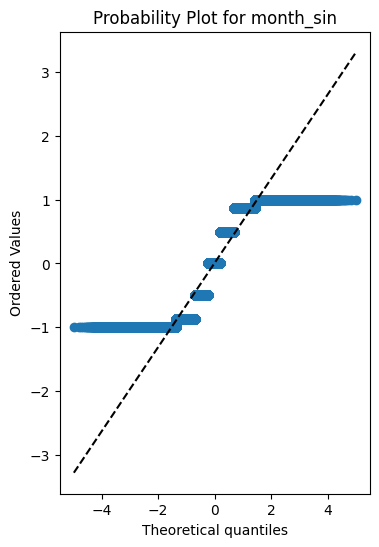

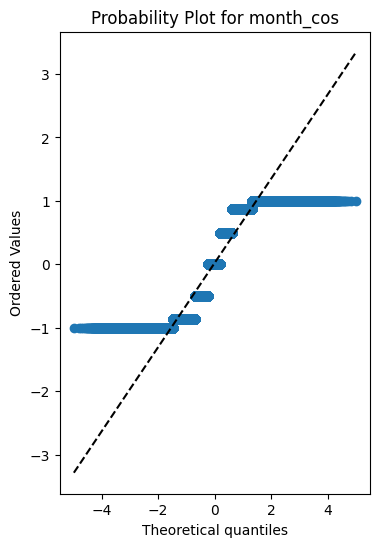

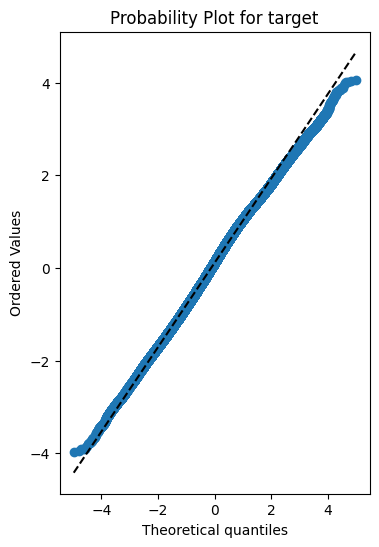

In [9]:
numerical_cols = train.select_dtypes(include=np.number)


for col in numerical_cols.columns:
    fig, ax = plt.subplots(figsize=(4, 6))
    ss.probplot(numerical_cols[col], dist="norm", plot=ax)
    ax.set_title(f'Probability Plot for {col}') # Add title for clarity

    # Customize the line and point appearance via Matplotlib
    ax.get_lines()[0].set_color(sns.color_palette()[0])  # Points match Seaborn palette
    ax.get_lines()[1].set_color("black")  # Reference line
    ax.get_lines()[1].set_linestyle("--")

    plt.show()

In [10]:
numerical_cols

,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
0,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,0.500000,-0.866025,0.207665
1,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,0.500000,-0.866025,0.634465
2,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,0.500000,-0.866025,-0.337083
3,-54.5,-70.5,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,0.500000,-0.866025,-0.148142
4,-54.5,-69.5,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,0.500000,-0.866025,0.089539
...,...,...,...,...,...,...,...,...,...,...,...
2154016,83.5,-31.5,-0.129312,0.124389,0.272274,0.295614,-0.462034,0.259676,-0.866025,-0.500000,-0.274003
2154017,83.5,-30.5,-0.124017,0.201431,0.254657,0.251846,-0.474233,0.157584,-0.866025,-0.500000,-0.271390
2154018,83.5,-29.5,-0.118744,0.216207,0.209865,0.229952,-0.446193,0.113499,-0.866025,-0.500000,-0.268540
2154019,83.5,-28.5,-0.113457,0.102946,0.209712,0.165252,-0.417426,-0.248551,-0.866025,-0.500000,-0.265412


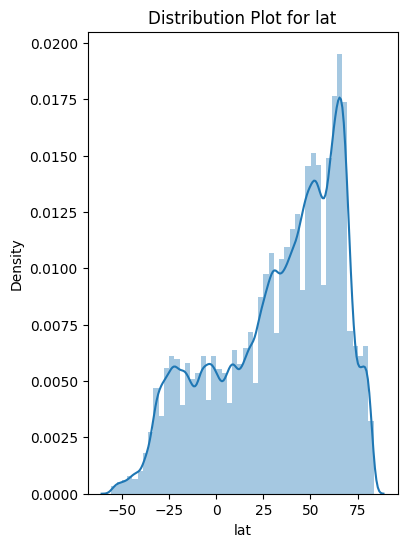

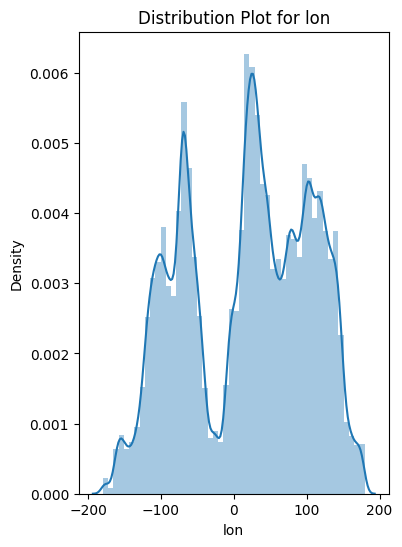

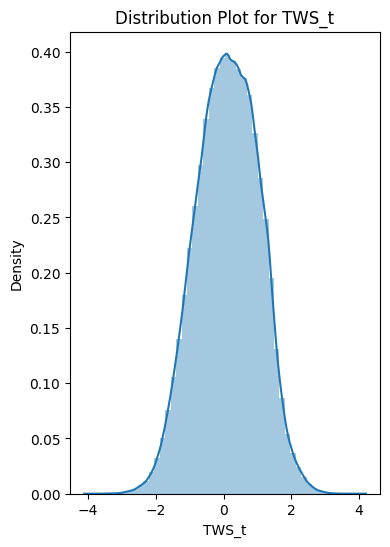

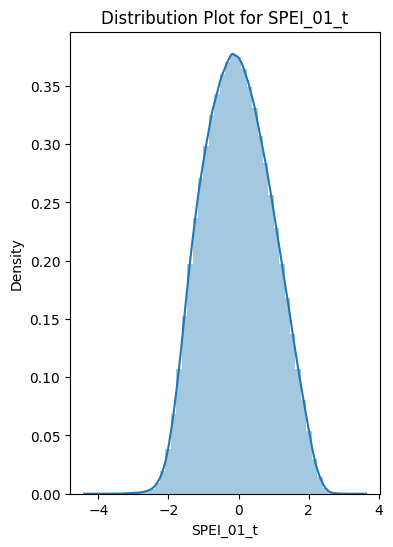

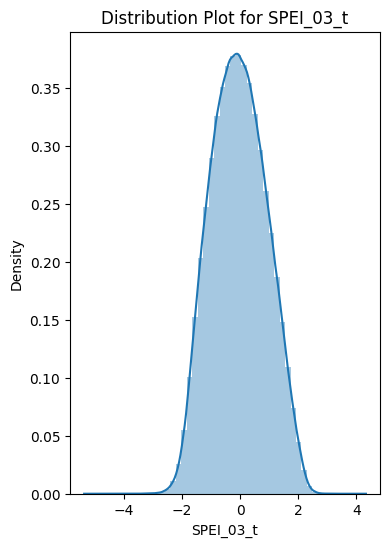

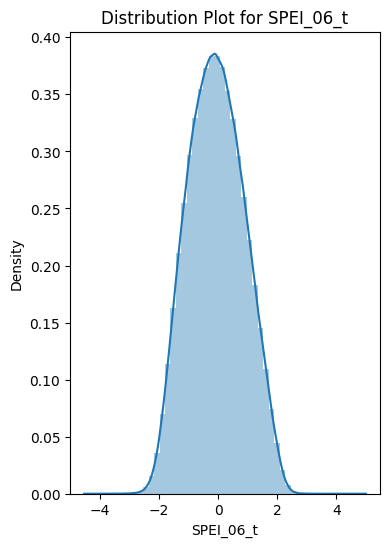

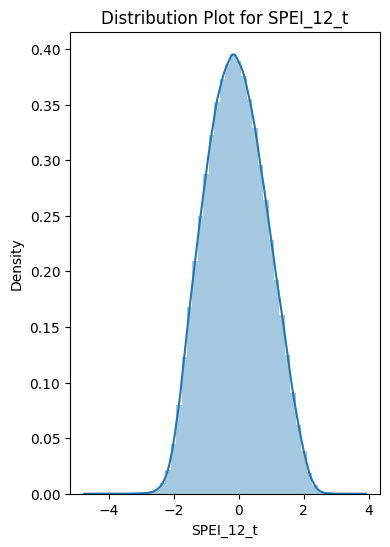

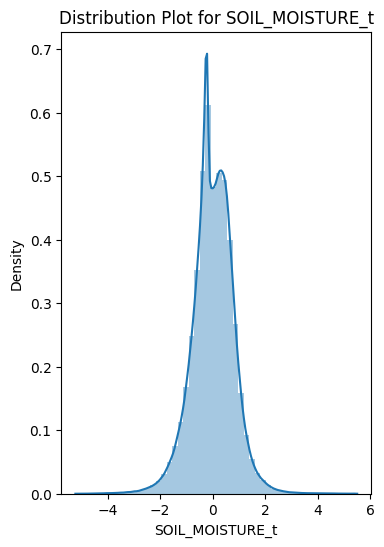

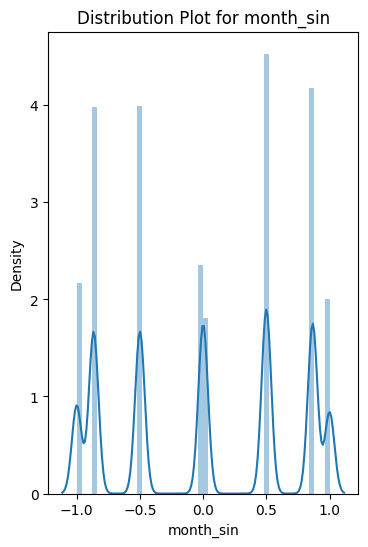

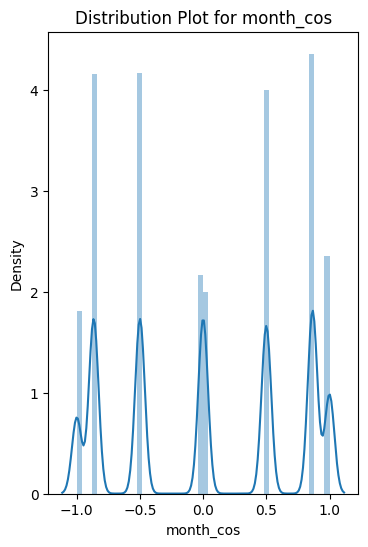

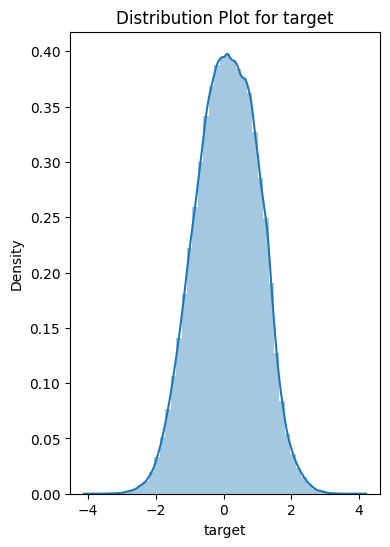

In [11]:
#Distribution plots for each one i guess
for col in numerical_cols.columns:
    fig, ax = plt.subplots(figsize=(4, 6))
    sns.distplot(numerical_cols[col])
    ax.set_title(f'Distribution Plot for {col}') # Add title for clarity

    plt.show()

## Preprocessing and Feature Engineering

In [12]:
#Transform the target to logarithmic values for better visualization
train["target"] = np.log1p(train["target"])

train["time"] = pd.to_datetime(train["time"])
test["time"] = pd.to_datetime(test["time"])

train = train.set_index("time")
test = test.set_index("time")

train = train.sort_values(by=["time", "lat", "lon"])
test = test.sort_values(by=["time", "lat", "lon"])

In [13]:
train

,sample_id,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
time,,,,,,,,,,,,
2002-05-01,20020501_-55.5_-68.5,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,0.500000,-0.866025,0.188689
2002-05-01,20020501_-55.5_-67.5,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,0.500000,-0.866025,0.491316
2002-05-01,20020501_-54.5_-71.5,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,0.500000,-0.866025,-0.411105
2002-05-01,20020501_-54.5_-70.5,-54.5,-70.5,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,0.500000,-0.866025,-0.160335
2002-05-01,20020501_-54.5_-69.5,-54.5,-69.5,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,0.500000,-0.866025,0.085755
...,...,...,...,...,...,...,...,...,...,...,...,...
2015-08-01,20150801_83.5_-31.5,83.5,-31.5,-0.129312,0.124389,0.272274,0.295614,-0.462034,0.259676,-0.866025,-0.500000,-0.320209
2015-08-01,20150801_83.5_-30.5,83.5,-30.5,-0.124017,0.201431,0.254657,0.251846,-0.474233,0.157584,-0.866025,-0.500000,-0.316616
2015-08-01,20150801_83.5_-29.5,83.5,-29.5,-0.118744,0.216207,0.209865,0.229952,-0.446193,0.113499,-0.866025,-0.500000,-0.312713


In [14]:
def feature_engineer(df):
  df = df.copy()

  # Calendar features
  df["year"] = df.index.year
  df["month"] = df.index.month

  # Cyclical seasonality
  df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
  df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

  # Location grouping
  groups = df.groupby(["lat", "lon"], group_keys=False)

  # Variables to engineer
  variables = [
      "SPEI_01_t",
      "SPEI_03_t",
      "SPEI_06_t",
      "SPEI_12_t",
      "SOIL_MOISTURE_t"
  ]

  for col in variables:

      # Lagged values
      df[f"{col}_lag1"] = groups[col].shift(1)
      df[f"{col}_lag3"] = groups[col].shift(3)
      df[f"{col}_lag6"] = groups[col].shift(6)

      # Changes
      df[f"{col}_diff1"] = (
          df[col] - df[f"{col}_lag1"]
      )

      df[f"{col}_diff3"] = (
          df[col] - df[f"{col}_lag3"]
      )

      # Rolling statistics
      for window in [3, 6, 12]:

          df[f"{col}_rollmean{window}"] = (
              groups[col]
              .transform(lambda x: x.rolling(window).mean())
          )

          df[f"{col}_rollstd{window}"] = (
              groups[col]
              .transform(lambda x: x.rolling(window).std())
          )

  # Multi-timescale SPEI contrasts (moved outside the loop)
  # These are based on the original columns, not the engineered ones.
  if "SPEI_01_t" in df.columns and "SPEI_12_t" in df.columns:
      df["SPEI_short_long"] = (
          df["SPEI_01_t"] - df["SPEI_12_t"]
      )
  if "SPEI_03_t" in df.columns and "SPEI_12_t" in df.columns:
      df["SPEI_medium_long"] = (
          df["SPEI_03_t"] - df["SPEI_12_t"]
      )
  if "SPEI_03_t" in df.columns and "SPEI_06_t" in df.columns:
      df["SPEI_03_06"] = (
          df["SPEI_03_t"] - df["SPEI_06_t"]
      )

  return df


In [15]:
class ExplainableGARCH(
    BaseEstimator,
    TransformerMixin
):

    def __init__(
        self,
        p=1,
        q=1,
        mean="Constant",
        vol="GARCH",
        dist="t",
        rescale=True
    ):

        self.p = p
        self.q = q
        self.mean = mean
        self.vol = vol
        self.dist = dist
        self.rescale = rescale


    def fit(self, X, y):

        y = np.asarray(
            y,
            dtype=float
        ).ravel()

        self.model_ = arch_model(

            y,

            mean=self.mean,

            vol=self.vol,

            p=self.p,

            q=self.q,

            dist=self.dist,

            rescale=self.rescale

        )

        self.result_ = self.model_.fit(
            disp="off"
        )


        # ----------------------------------------------------
        # Parameters
        # ----------------------------------------------------

        self.params_ = (
            self.result_.params
        )


        # ----------------------------------------------------
        # Conditional volatility
        # ----------------------------------------------------

        self.conditional_volatility_ = np.asarray(
            self.result_.conditional_volatility
        )


        # ----------------------------------------------------
        # Conditional variance
        # ----------------------------------------------------

        self.conditional_variance_ = (
            self.conditional_volatility_ ** 2
        )


        # ----------------------------------------------------
        # Residuals
        # ----------------------------------------------------

        self.residuals_ = np.asarray(
            self.result_.resid
        )


        # ----------------------------------------------------
        # Standardized residuals
        # ----------------------------------------------------

        self.standardized_residuals_ = (

            self.residuals_
            /
            np.maximum(
                self.conditional_volatility_,
                1e-8
            )

        )


        # ----------------------------------------------------
        # Model statistics
        # ----------------------------------------------------

        self.aic_ = self.result_.aic

        self.bic_ = self.result_.bic

        self.loglikelihood_ = (
            self.result_.loglikelihood
        )


        return self


    def transform(self, X):

        X = np.asarray(X)

        n = len(X)


        volatility = (
            self.conditional_volatility_
        )[-n:]


        variance = (
            self.conditional_variance_
        )[-n:]


        standardized_residuals = (
            self.standardized_residuals_
        )[-n:]


        return np.column_stack([

            X,

            volatility,

            variance,

            standardized_residuals

        ])


    def get_volatility(self):

        return self.conditional_volatility_


    def get_variance(self):

        return self.conditional_variance_


    def get_residuals(self):

        return self.residuals_


    def get_standardized_residuals(self):

        return self.standardized_residuals_


    def get_parameters(self):

        return self.params_


    def get_model_statistics(self):

        return {

            "AIC": self.aic_,

            "BIC": self.bic_,

            "loglikelihood":
                self.loglikelihood_

        }

In [16]:
train = feature_engineer(train)
test = feature_engineer(test)


train_numerical_cols = train.select_dtypes(include=np.number)
train = train.fillna(train_numerical_cols.median())


test_numerical_cols = test.select_dtypes(include=np.number)
test = test.fillna(test_numerical_cols.median())


In [17]:
train["target"]

,target
time,
2002-05-01,0.188689
2002-05-01,0.491316
2002-05-01,-0.411105
2002-05-01,-0.160335
2002-05-01,0.085755
...,...
2015-08-01,-0.320209
2015-08-01,-0.316616
2015-08-01,-0.312713


In [18]:
test

,ID,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,...,SOIL_MOISTURE_t_diff3,SOIL_MOISTURE_t_rollmean3,SOIL_MOISTURE_t_rollstd3,SOIL_MOISTURE_t_rollmean6,SOIL_MOISTURE_t_rollstd6,SOIL_MOISTURE_t_rollmean12,SOIL_MOISTURE_t_rollstd12,SPEI_short_long,SPEI_medium_long,SPEI_03_06
time,,,,,,,,,,,,,,,,,,,,,
2015-09-01,20150901_-55.5_-68.5,-55.5,-68.5,-0.373966,-0.024582,0.958610,0.549351,1.264457,-0.474105,-1.000000e+00,...,-0.015708,0.064195,0.256529,0.071554,0.401237,0.057903,0.527093,-1.289038,-0.305847,0.409259
2015-09-01,20150901_-55.5_-67.5,-55.5,-67.5,-0.530701,-0.049041,1.070304,0.526642,1.267029,-0.217645,-1.000000e+00,...,-0.015708,0.064195,0.256529,0.071554,0.401237,0.057903,0.527093,-1.316070,-0.196725,0.543662
2015-09-01,20150901_-54.5_-71.5,-54.5,-71.5,0.531723,0.661190,1.189847,0.924421,0.851582,-0.574531,-1.000000e+00,...,-0.015708,0.064195,0.256529,0.071554,0.401237,0.057903,0.527093,-0.190392,0.338265,0.265427
2015-09-01,20150901_-54.5_-70.5,-54.5,-70.5,0.310179,0.894951,1.310615,1.090452,1.161290,-1.140090,-1.000000e+00,...,-0.015708,0.064195,0.256529,0.071554,0.401237,0.057903,0.527093,-0.266339,0.149324,0.220163
2015-09-01,20150901_-54.5_-69.5,-54.5,-69.5,0.110071,1.167738,1.462231,1.291645,1.247388,-1.581409,-1.000000e+00,...,-0.015708,0.064195,0.256529,0.071554,0.401237,0.057903,0.527093,-0.079649,0.214843,0.170586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01,20181201_83.5_-31.5,83.5,-31.5,-0.170790,1.311603,-0.321355,-0.427072,-0.635734,0.578842,-2.449294e-16,...,0.962388,0.291870,0.500843,-0.008059,0.458325,-0.178454,0.383329,1.947337,0.314379,0.105717
2018-12-01,20181201_83.5_-30.5,83.5,-30.5,-0.170790,1.400398,-0.349135,-0.437496,-0.595984,0.673546,-2.449294e-16,...,0.692381,0.385732,0.496109,0.203711,0.372448,0.065488,0.327468,1.996382,0.246849,0.088361
2018-12-01,20181201_83.5_-29.5,83.5,-29.5,-0.170790,1.412066,-0.363698,-0.513165,-0.664792,0.497807,-2.449294e-16,...,0.511917,0.228343,0.448245,0.132714,0.303578,0.020389,0.322245,2.076858,0.301094,0.149467


## Modelling

In [19]:
ridge = Pipeline([

    ("scaler", StandardScaler()),

    ("pca", TruncatedSVD()),


    ("ridge", Ridge(
        alpha=1.0
    ))

])


lasso = Pipeline([

    ("scaler", StandardScaler()),

    ("pca", TruncatedSVD()),

    ("lasso", Lasso(
        alpha=0.001,
        max_iter=10000
    ))

])


extra_trees = Pipeline([

    ("transformer", QuantileTransformer(
        output_distribution="normal"
    )),

    ("extra_trees", ExtraTreesRegressor(

        n_estimators=500,

        min_samples_leaf=2,

        max_features=1.0,

        random_state=42,

        n_jobs=-1

    ))

])


xgb = Pipeline([

    ("transformer", QuantileTransformer(
        output_distribution="normal"
    )),


    ("xgb", XGBRegressor(

        n_estimators=500,

        learning_rate=0.05,

        max_depth=6,

        min_child_weight=3,

        subsample=0.8,

        colsample_bytree=0.8,

        reg_alpha=0.0,

        reg_lambda=1.0,

        objective="reg:squarederror",

        random_state=42,

        n_jobs=-1

    ))

])


lgbm = Pipeline([

    ("transformer", QuantileTransformer(
        output_distribution="normal"
    )),


    ("lgbm", LGBMRegressor(

        n_estimators=500,

        learning_rate=0.05,

        num_leaves=31,

        max_depth=-1,

        min_child_samples=20,

        subsample=0.8,

        colsample_bytree=0.8,

        reg_alpha=0.0,

        reg_lambda=1.0,

        random_state=42,

        n_jobs=-1,

        verbosity=-1

    ))

])


catboost = Pipeline([

    ("transformer", QuantileTransformer(
        output_distribution="normal"
    )),


    ("catboost", CatBoostRegressor(

        iterations=500,

        learning_rate=0.05,

        depth=6,

        l2_leaf_reg=3.0,

        loss_function="RMSE",

        random_seed=42,

        verbose=False,

        thread_count=-1

    ))

])

In [20]:
X = train.drop(columns=["target", "sample_id"], axis=1)
y = train["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
def weighted_r2(y_true, y_pred, sample_weight=None):
    return r2_score(
        y_true,
        y_pred,
        sample_weight=sample_weight
    )


def weighted_mape(y_true, y_pred, sample_weight=None, epsilon=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = np.maximum(np.abs(y_true), epsilon)

    ape = np.abs(
        (y_true - y_pred) / denominator
    )

    if sample_weight is None:
        return np.mean(ape) * 100

    sample_weight = np.asarray(sample_weight)

    return (
        np.sum(sample_weight * ape)
        / np.sum(sample_weight)
    ) * 100



models = {
    "ridge": ridge,
    "lasso": lasso,
    "xgb": xgb,
    "lgbm": lgbm,
    "catboost": catboost
}




cv = TimeSeriesSplit(
    n_splits=5
)

extra_trees.set_params(
    extra_trees__n_jobs=1
)

xgb.set_params(
    xgb__n_jobs=1
)

lgbm.set_params(
    lgbm__n_jobs=1
)

catboost.set_params(
    catboost__thread_count=1
)



mlflow.set_experiment("HMM Guided Model Experiments")

results = []

for name, model in models.items():

    print(
        "\n" + "=" * 80
    )

    print(
        f"MODEL: {name.upper()}"
    )

    print(
        "=" * 80
    )


    with mlflow.start_run(
        run_name=f"{name}_model_inference"
    ):



        mlflow.log_param(
            "model",
            name
        )

        mlflow.log_param(
            "cv",
            "TimeSeriesSplit"
        )

        mlflow.log_param(
            "n_splits",
            5
        )

        mlflow.log_param(
            "markov_regression",
            True
        )

        mlflow.log_param(
            "n_regimes",
            2
        )



        fold_r2 = []

        fold_mape = []

        fold_rmse = []

        fold_mae = []


        all_y_true = []

        all_y_pred = []

        all_residuals = []

        all_times = []




        for fold, (
            train_idx,
            val_idx
        ) in enumerate(
            cv.split(X),
            start=1
        ):

            print(
                "\n" + "-" * 70
            )

            print(
                f"Fold {fold}"
            )

            print(
                "-" * 70
            )


            X_train = X.iloc[
                train_idx
            ]

            X_val = X.iloc[
                val_idx
            ]


            y_train = y.iloc[
                train_idx
            ]

            y_val = y.iloc[
                val_idx
            ]




            model.fit(
                X_train,
                y_train
            )



            y_pred = model.predict(
                X_val
            )


            y_pred = np.asarray(
                y_pred
            )



            residuals = (
                y_val.to_numpy()
                -
                y_pred
            )




            r2 = weighted_r2(
                y_val,
                y_pred
            )


            mape = weighted_mape(
                y_val,
                y_pred
            )


            rmse = np.sqrt(
                mean_squared_error(
                    y_val,
                    y_pred
                )
            )


            mae = mean_absolute_error(
                y_val,
                y_pred
            )



            fold_r2.append(
                r2
            )

            fold_mape.append(
                mape
            )

            fold_rmse.append(
                rmse
            )

            fold_mae.append(
                mae
            )




            all_y_true.extend(
                y_val.to_numpy()
            )

            all_y_pred.extend(
                y_pred
            )

            all_residuals.extend(
                residuals
            )




            if hasattr(
                X_val,
                "index"
            ):

                all_times.extend(
                    X_val.index
                )



            print(
                f"Fold {fold:02d} | "
                f"R²: {r2:.4f} | "
                f"MAPE: {mape:.2f}% | "
                f"RMSE: {rmse:.4f} | "
                f"MAE: {mae:.4f}"
            )



        mean_r2 = np.mean(
            fold_r2
        )

        std_r2 = np.std(
            fold_r2
        )


        mean_mape = np.mean(
            fold_mape
        )

        std_mape = np.std(
            fold_mape
        )


        mean_rmse = np.mean(
            fold_rmse
        )

        std_rmse = np.std(
            fold_rmse
        )


        mean_mae = np.mean(
            fold_mae
        )

        std_mae = np.std(
            fold_mae
        )


        print(
            "\nCV SUMMARY"
        )

        print(
            "-" * 60
        )


        print(
            f"Weighted R²  : "
            f"{mean_r2:.4f} ± {std_r2:.4f}"
        )

        print(
            f"Weighted MAPE: "
            f"{mean_mape:.2f}% ± {std_mape:.2f}%"
        )

        print(
            f"RMSE         : "
            f"{mean_rmse:.4f} ± {std_rmse:.4f}"
        )

        print(
            f"MAE          : "
            f"{mean_mae:.4f} ± {std_mae:.4f}"
        )




        mlflow.log_metric(
            "cv_weighted_r2",
            mean_r2
        )

        mlflow.log_metric(
            "cv_weighted_r2_std",
            std_r2
        )

        mlflow.log_metric(
            "cv_weighted_mape",
            mean_mape
        )

        mlflow.log_metric(
            "cv_weighted_mape_std",
            std_mape
        )

        mlflow.log_metric(
            "cv_rmse",
            mean_rmse
        )

        mlflow.log_metric(
            "cv_rmse_std",
            std_rmse
        )

        mlflow.log_metric(
            "cv_mae",
            mean_mae
        )

        mlflow.log_metric(
            "cv_mae_std",
            std_mae
        )



        residual_df = pd.DataFrame({

            "y_true":
                all_y_true,

            "y_pred":
                all_y_pred,

            "residual":
                all_residuals

        })


        # Add time if available

        if len(all_times) == len(
            residual_df
        ):

            residual_df["time"] = (
                all_times
            )



        print(
            "\nRESIDUAL SUMMARY"
        )

        print(
            "-" * 60
        )

        print(
            residual_df[
                "residual"
            ].describe()
        )


        print(
            f"\nResidual mean: "
            f"{residual_df['residual'].mean():.6f}"
        )

        print(
            f"Residual std : "
            f"{residual_df['residual'].std():.6f}"
        )



        residual_path = (
            f"{name}_residuals.csv"
        )


        residual_df.to_csv(
            residual_path,
            index=False
        )


        mlflow.log_artifact(
            residual_path
        )



        plt.figure(
            figsize=(9, 6)
        )


        plt.scatter(
            residual_df["y_pred"],
            residual_df["residual"],
            alpha=0.25,
            s=10
        )


        plt.axhline(
            0,
            linestyle="--"
        )


        plt.xlabel(
            "Predicted value"
        )

        plt.ylabel(
            "Residual"
        )

        plt.title(
            f"{name.upper()} — Residuals vs Predictions"
        )


        plt.tight_layout()


        residual_plot = (
            f"{name}_residuals_vs_predictions.png"
        )


        plt.savefig(
            residual_plot,
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()


        mlflow.log_artifact(
            residual_plot
        )



        plt.figure(
            figsize=(9, 6)
        )


        plt.hist(
            residual_df["residual"],
            bins=50,
            alpha=0.8
        )


        plt.axvline(
            0,
            linestyle="--"
        )


        plt.xlabel(
            "Residual"
        )

        plt.ylabel(
            "Frequency"
        )

        plt.title(
            f"{name.upper()} — Residual Distribution"
        )


        plt.tight_layout()


        residual_distribution = (
            f"{name}_residual_distribution.png"
        )


        plt.savefig(
            residual_distribution,
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()


        mlflow.log_artifact(
            residual_distribution
        )


        if "time" in residual_df.columns:

            residual_time_df = (
                residual_df
                .copy()
            )


            residual_time_df["time"] = (
                pd.to_datetime(
                    residual_time_df["time"]
                )
            )


            residual_time_df = (
                residual_time_df
                .sort_values(
                    "time"
                )
            )


            plt.figure(
                figsize=(12, 6)
            )


            plt.scatter(
                residual_time_df["time"],
                residual_time_df["residual"],
                alpha=0.20,
                s=8
            )


            plt.axhline(
                0,
                linestyle="--"
            )


            plt.xlabel(
                "Time"
            )

            plt.ylabel(
                "Residual"
            )

            plt.title(
                f"{name.upper()} — Residuals Over Time"
            )


            plt.tight_layout()


            residual_time_plot = (
                f"{name}_residuals_over_time.png"
            )


            plt.savefig(
                residual_time_plot,
                dpi=300,
                bbox_inches="tight"
            )

            plt.close()


            mlflow.log_artifact(
                residual_time_plot
            )



        results.append({

            "model":
                name,

            "weighted_r2_mean":
                mean_r2,

            "weighted_r2_std":
                std_r2,

            "weighted_mape_mean":
                mean_mape,

            "weighted_mape_std":
                std_mape,

            "rmse_mean":
                mean_rmse,

            "rmse_std":
                std_rmse,

            "mae_mean":
                mean_mae,

            "mae_std":
                std_mae

        })



results_df = (

    pd.DataFrame(
        results
    )

    .sort_values(
        "weighted_r2_mean",
        ascending=False
    )

)


print(
    "\n"
    + "=" * 80
)

print(
    "FINAL MODEL COMPARISON"
)

print(
    "=" * 80
)


print(
    results_df.to_string(
        index=False
    )
)




MODEL: RIDGE

----------------------------------------------------------------------
Fold 1
----------------------------------------------------------------------
Fold 01 | R²: 0.0544 | MAPE: 322.50% | RMSE: 0.8737 | MAE: 0.5981

----------------------------------------------------------------------
Fold 2
----------------------------------------------------------------------
Fold 02 | R²: 0.0478 | MAPE: 222.27% | RMSE: 0.8117 | MAE: 0.5520

----------------------------------------------------------------------
Fold 3
----------------------------------------------------------------------
Fold 03 | R²: 0.0566 | MAPE: 277.40% | RMSE: 0.7794 | MAE: 0.5077

----------------------------------------------------------------------
Fold 4
----------------------------------------------------------------------
Fold 04 | R²: 0.0728 | MAPE: 264.40% | RMSE: 0.7788 | MAE: 0.5113

----------------------------------------------------------------------
Fold 5
-------------------------------------------

## Test Prediction

In [22]:
test

,ID,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,...,SOIL_MOISTURE_t_diff3,SOIL_MOISTURE_t_rollmean3,SOIL_MOISTURE_t_rollstd3,SOIL_MOISTURE_t_rollmean6,SOIL_MOISTURE_t_rollstd6,SOIL_MOISTURE_t_rollmean12,SOIL_MOISTURE_t_rollstd12,SPEI_short_long,SPEI_medium_long,SPEI_03_06
time,,,,,,,,,,,,,,,,,,,,,
2015-09-01,20150901_-55.5_-68.5,-55.5,-68.5,-0.373966,-0.024582,0.958610,0.549351,1.264457,-0.474105,-1.000000e+00,...,-0.015708,0.064195,0.256529,0.071554,0.401237,0.057903,0.527093,-1.289038,-0.305847,0.409259
2015-09-01,20150901_-55.5_-67.5,-55.5,-67.5,-0.530701,-0.049041,1.070304,0.526642,1.267029,-0.217645,-1.000000e+00,...,-0.015708,0.064195,0.256529,0.071554,0.401237,0.057903,0.527093,-1.316070,-0.196725,0.543662
2015-09-01,20150901_-54.5_-71.5,-54.5,-71.5,0.531723,0.661190,1.189847,0.924421,0.851582,-0.574531,-1.000000e+00,...,-0.015708,0.064195,0.256529,0.071554,0.401237,0.057903,0.527093,-0.190392,0.338265,0.265427
2015-09-01,20150901_-54.5_-70.5,-54.5,-70.5,0.310179,0.894951,1.310615,1.090452,1.161290,-1.140090,-1.000000e+00,...,-0.015708,0.064195,0.256529,0.071554,0.401237,0.057903,0.527093,-0.266339,0.149324,0.220163
2015-09-01,20150901_-54.5_-69.5,-54.5,-69.5,0.110071,1.167738,1.462231,1.291645,1.247388,-1.581409,-1.000000e+00,...,-0.015708,0.064195,0.256529,0.071554,0.401237,0.057903,0.527093,-0.079649,0.214843,0.170586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01,20181201_83.5_-31.5,83.5,-31.5,-0.170790,1.311603,-0.321355,-0.427072,-0.635734,0.578842,-2.449294e-16,...,0.962388,0.291870,0.500843,-0.008059,0.458325,-0.178454,0.383329,1.947337,0.314379,0.105717
2018-12-01,20181201_83.5_-30.5,83.5,-30.5,-0.170790,1.400398,-0.349135,-0.437496,-0.595984,0.673546,-2.449294e-16,...,0.692381,0.385732,0.496109,0.203711,0.372448,0.065488,0.327468,1.996382,0.246849,0.088361
2018-12-01,20181201_83.5_-29.5,83.5,-29.5,-0.170790,1.412066,-0.363698,-0.513165,-0.664792,0.497807,-2.449294e-16,...,0.511917,0.228343,0.448245,0.132714,0.303578,0.020389,0.322245,2.076858,0.301094,0.149467


In [24]:
len(train.columns) == len(test.columns)

True

In [26]:
test_id = test["ID"]

test = test.drop(columns=["ID"])

KeyError: 'ID'

In [27]:
test = test.drop(columns=["TWS_t_masked"])

preds = models["lgbm"].predict(test)

true_preds = np.expm1(preds)

In [29]:
submission = pd.DataFrame({
    "ID": test_id,
    "Target": true_preds
})

In [31]:
submission.to_csv("submission.csv", index=False)

In [32]:
shutil.make_archive("mlruns", "zip", "mlruns")
shutil.make_archive("catboost_info", "zip", "catboost_info")

'/content/catboost_info.zip'